# Global Meteorite Landings Analysis 2026

**Author:** Elitsa Trifonova  
**Dataset source:** [Kaggle meteorite landings dataset](https://www.kaggle.com/datasets/ulrikthygepedersen/meteorite-landings/data)

This project explores global meteorite landings using Python, pandas, and matplotlib.

## Project aims

This analysis explores:
- how meteorite discoveries changed over time,
- the most common meteorite classes,
- the heaviest meteorites in the dataset,
- the difference between meteorites that fell and were found,
- and where meteorites are recorded most often.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "meteorite_landings.csv"

In [2]:
def load_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

def clean_data(meteor: pd.DataFrame) -> pd.DataFrame:
    meteor = meteor.dropna(subset=["reclat", "reclong", "year", "mass (g)"])
    meteor = meteor[(meteor["reclat"] != 0) & (meteor["reclong"] != 0)]
    meteor["year"] = pd.to_numeric(meteor["year"], errors="coerce")
    meteor["mass (g)"] = pd.to_numeric(meteor["mass (g)"], errors="coerce")
    meteor = meteor.dropna(subset=["year", "mass (g)"])
    meteor = meteor[(meteor["year"] >= 1800) & (meteor["year"] <= 2026)]
    meteor["year"] = meteor["year"].astype(int)
    return meteor

In [3]:
meteor = load_data(DATA_PATH)
meteor.info()
meteor.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB


,id,mass (g),year,reclat,reclong
count,45716.000000,4.558500e+04,45425.000000,38401.000000,38401.000000
mean,26889.735104,1.327808e+04,1991.828817,-39.122580,61.074319
std,16860.683030,5.749889e+05,25.052766,46.378511,80.647298
min,1.000000,0.000000e+00,860.000000,-87.366670,-165.433330
25%,12688.750000,7.200000e+00,1987.000000,-76.714240,0.000000
50%,24261.500000,3.260000e+01,1998.000000,-71.500000,35.666670
75%,40656.750000,2.026000e+02,2003.000000,0.000000,157.166670
max,57458.000000,6.000000e+07,2101.000000,81.166670,354.473330


## Data cleaning

The dataset was cleaned by removing rows with missing or invalid coordinates, converting year and mass to numeric values, and excluding invalid year values.

In [ ]:
meteor = clean_data(meteor)
meteor.head()

## 1. Fell vs found

In [4]:
meteor["fall"].value_counts()

fall
Found    44609
Fell      1107
Name: count, dtype: int64

## 2. Most common meteorite types

In [5]:
meteor["recclass"].value_counts().head(10)

recclass
L6      8285
H5      7142
L5      4796
H6      4528
H4      4211
LL5     2766
LL6     2043
L4      1253
H4/5     428
CM2      416
Name: count, dtype: int64

## 3. Largest meteorites

In [6]:
meteor.sort_values("mass (g)", ascending=False)[["name", "mass (g)", "year", "recclass"]].head(5)

,name,mass (g),year,recclass
16392,Hoba,60000000.0,1920.0,"Iron, IVB"
5373,Cape York,58200000.0,1818.0,"Iron, IIIAB"
5365,Campo del Cielo,50000000.0,1575.0,"Iron, IAB-MG"
5370,Canyon Diablo,30000000.0,1891.0,"Iron, IAB-MG"
3455,Armanty,28000000.0,1898.0,"Iron, IIIE"


## 4. Meteorites recorded over time

In [7]:
meteorites_per_year = meteor["year"].value_counts().sort_index()
meteorites_per_year

year
860.0        1
920.0        1
1399.0       1
1490.0       1
1491.0       1
          ... 
2010.0    1005
2011.0     713
2012.0     234
2013.0      11
2101.0       1
Name: count, Length: 265, dtype: int64

## 5. Where meteorites land most often

In [8]:
meteor[["reclat", "reclong"]].value_counts().head(10)

reclat     reclong   
 0.00000    0.00000      6214
-71.50000   35.66667     4761
-84.00000   168.00000    3040
-72.00000   26.00000     1505
-79.68333   159.75000     657
-76.71667   159.66667     637
-76.18333   157.16667     539
-79.68333   155.75000     473
-84.21667   160.50000     263
-86.36667  -70.00000      226
Name: count, dtype: int64

## Visualisation: Meteorite discoveries per year

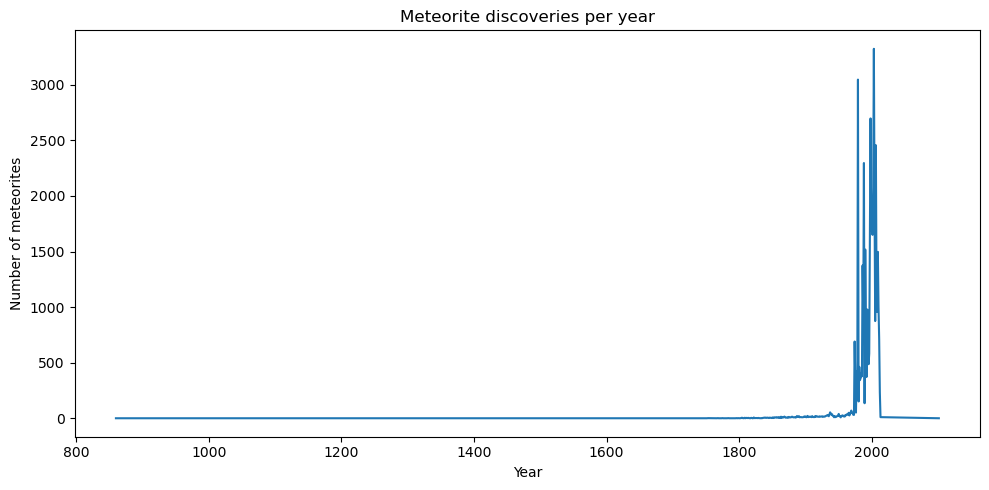

In [9]:
plt.figure(figsize=(10, 5))
meteorites_per_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of meteorites")
plt.title("Meteorite discoveries per year")
plt.tight_layout()
plt.show()

## Last 20 years

In [10]:
meteorites_per_year.tail(20)

year
1995.0     487
1996.0     583
1997.0    1696
1998.0    2697
1999.0    1691
2000.0    1792
2001.0    1650
2002.0    2078
2003.0    3323
2004.0    1940
2005.0     875
2006.0    2456
2007.0    1189
2008.0     957
2009.0    1497
2010.0    1005
2011.0     713
2012.0     234
2013.0      11
2101.0       1
Name: count, dtype: int64

## Conclusion

This analysis explored a global meteorite landings dataset using Python and pandas. The results showed that most records are classified as found rather than fell, and that there is a wide range of meteorite types and masses. The data also contained quality issues such as missing coordinates and invalid year values, which were cleaned before analysis. This project provided a strong introduction to exploratory data analysis and created a foundation for future dashboard work.